# Channel Attention (SE-Block)

Eksperimen I/O untuk memahami pengaruh ChannelAttention terhadap gambar dari folder datasets.

In [13]:
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import numpy as np
def find_root(start):
    for p in [start] + list(start.parents):
        if (p / "basicsr").exists():
            return p
    return start
proj_dir = find_root(Path.cwd().resolve())
sys.path.append(str(proj_dir))
from basicsr.models.trifanet_model import ChannelAttention

In [14]:
data_dir = proj_dir / "datasets"
exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
img_paths = [p for p in data_dir.glob("*") if p.suffix.lower() in exts]
img_path = img_paths[0] if img_paths else None

In [15]:
from PIL import Image
def load_image(path, size=None):
    img = Image.open(path).convert("RGB")
    if size is not None:
        img = img.resize(size, Image.BILINEAR)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    t = torch.from_numpy(arr).permute(2,0,1).unsqueeze(0)
    return t

In [16]:
if img_path is None:
    H, W = 256, 256
    x = torch.zeros(1,3,H,W, dtype=torch.float32)
    xv = torch.linspace(0,1,W).view(1,1,1,W).expand(1,1,H,W)
    yv = torch.linspace(0,1,H).view(1,1,H,1).expand(1,1,H,W)
    x[:,0:1] = xv
    x[:,1:2] = yv
    x[:,2:3] = 1 - xv
else:
    x = load_image(img_path)

In [17]:
ca = ChannelAttention(num_feat=3, reduction=1)
print("Project root:", proj_dir)
print(f"Image path: {img_path}" if img_path is not None else "Synthetic image used")
print("x shape:", x.shape, "range:", (x.min().item(), x.max().item()))
with torch.no_grad():
    pool = ca.avg_pool(x)
    print("avg_pool -> shape:", pool.shape, "values:", pool.view(-1).cpu().numpy())
    y = ca.fc(pool.view(x.size(0), x.size(1))).view(x.size(0), x.size(1), 1, 1)
    print("weights -> shape:", y.shape, "values:", y.view(-1).cpu().numpy())
    out = x * y
print("out shape:", out.shape, "range:", (out.min().item(), out.max().item()))
w = y.squeeze().cpu().numpy()

Synthetic image used
x shape: torch.Size([1, 3, 256, 256]) range: (0.0, 1.0)
avg_pool -> shape: torch.Size([1, 3, 1, 1]) values: [0.5 0.5 0.5]
weights -> shape: torch.Size([1, 3, 1, 1]) values: [0.5 0.5 0.5]
out shape: torch.Size([1, 3, 256, 256]) range: (0.0, 0.5)


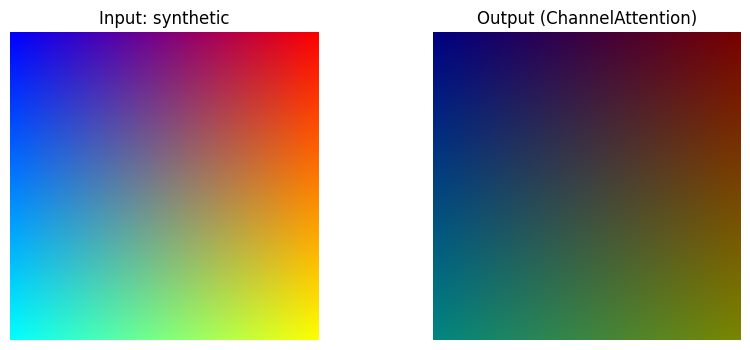

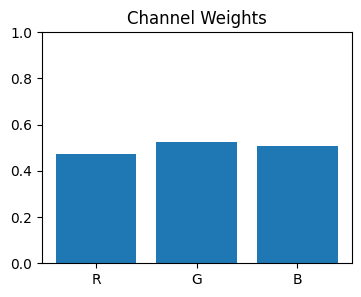

In [12]:
def to_numpy_img(t):
    t = t.squeeze(0).permute(1,2,0).clamp(0,1).cpu().numpy()
    return t
orig = to_numpy_img(x)
attn_out = to_numpy_img(out)
if img_path is not None:
    orig_pil = Image.open(img_path).convert("RGB")
    plt.figure(figsize=(5,5))
    plt.imshow(orig_pil)
    plt.title(f"Original file: {img_path.name}")
    plt.axis("off")
    plt.show()
fig, axes = plt.subplots(1,2, figsize=(10,4))
axes[0].imshow(orig)
axes[0].set_title(f"Input: {img_path.name if img_path else 'synthetic'}")
axes[0].axis("off")
axes[1].imshow(attn_out)
axes[1].set_title("Output (ChannelAttention)")
axes[1].axis("off")
plt.show()
plt.figure(figsize=(4,3))
plt.bar(["R","G","B"], w)
plt.ylim(0,1)
plt.title("Channel Weights")
plt.show()